In [1]:
# TEORIA:
# O gradiente de f em um ponto x é o vetor que aponta na direção
# de maior crescimento de f. Sua magnitude é a taxa de crescimento
# nessa direção.
#
# ∇f(x) = [∂f/∂x₁, ∂f/∂x₂, ..., ∂f/∂xₙ]
#
# Para minimizar f, andamos na direção OPOSTA ao gradiente:
#   x_{t+1} = x_t - α ∇f(x_t)
#
# Onde α é o learning rate — o tamanho do passo.
#
# GEOMETRIA:
# A superfície de loss é uma hipersuperfície em R^{p+1}.
# Gradiente descendente é uma bola rolando morro abaixo.
# O gradiente é o vetor normal à curva de nível naquele ponto.
#
# PARA REGRESSÃO LINEAR, o loss é convexo (bowl):
#   L(β) = ‖y - Xβ‖² = yᵀy - 2βᵀXᵀy + βᵀXᵀXβ
#   ∇L(β) = -2Xᵀ(y - Xβ) = 2Xᵀ(Xβ - y)
#
# Setando ∇L = 0 → equação normal (commit 06).
# Gradiente descendente converge iterativamente para o mesmo ponto.
#
# CONDIÇÃO DE CONVERGÊNCIA:
# Para GD com loss quadrático, α < 2/λ_max onde λ_max é o maior
# autovalor de XᵀX. Isso conecta diretamente com o commit 03.
#
# VARIANTES:
# - Batch GD: usa todos os n exemplos por passo (lento, exato)
# - SGD: usa 1 exemplo (ruidoso, rápido, escapa de mínimos locais)
# - Mini-batch: usa k exemplos (equilíbrio — padrão em DL)


In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Antes de usar fórmulas analíticas, vamos verificar o gradiente
# numericamente via diferença finita:
#   ∂f/∂xᵢ ≈ (f(x + ε·eᵢ) - f(x - ε·eᵢ)) / (2ε)

def f(x):
    """f(x,y) = x² + 2y² + xy — superfície quadrática."""
    return x[0]**2 + 2*x[1]**2 + x[0]*x[1]

def grad_f_analitico(x):
    """∇f = [2x + y, 4y + x]"""
    return np.array([2*x[0] + x[1], 4*x[1] + x[0]])

def grad_numerico(f, x, eps=1e-5):
    """Gradiente via diferença central."""
    g = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        ei = np.zeros_like(x, dtype=float)
        ei[i] = 1.
        g[i] = (f(x + eps*ei) - f(x - eps*ei)) / (2*eps)
    return g

x0 = np.array([3., 2.])
ga = grad_f_analitico(x0)
gn = grad_numerico(f, x0)
print(f"Gradiente analítico: {ga}")
print(f"Gradiente numérico:  {gn}")
print(f"Diferença: {np.abs(ga - gn)}")  # deve ser < 1e-9


Gradiente analítico: [ 8. 11.]
Gradiente numérico:  [ 8. 11.]
Diferença: [5.24096322e-11 2.94106073e-10]


In [4]:
np.random.seed(88)
n, p = 100, 2
X = np.random.randn(n, p)
X = np.column_stack([np.ones(n), X])  # intercepto
beta_true = np.array([1., 2., -1.])
y = X @ beta_true + 0.5 * np.random.randn(n)

def loss_mse(beta, X, y):
    r = y - X @ beta
    return np.dot(r, r) / len(y)

def grad_mse(beta, X, y):
    """∇L = -2Xᵀ(y - Xβ) / n"""
    r = y - X @ beta
    return -2 * X.T @ r / len(y)

# Learning rate ideal: α < 2 / λ_max(XᵀX/n)
XtX = X.T @ X / n
lambda_max = np.linalg.eigvalsh(XtX).max()
alpha_max = 2. / lambda_max
print(f"\nλ_max(XᵀX/n) = {lambda_max:.4f}")
print(f"α máximo para convergência: {alpha_max:.4f}")

# Experimento com diferentes learning rates
def gradient_descent(beta_init, alpha, n_iter, X, y):
    beta = beta_init.copy()
    historico = [loss_mse(beta, X, y)]
    betas = [beta.copy()]
    for _ in range(n_iter):
        g = grad_mse(beta, X, y)
        beta = beta - alpha * g
        historico.append(loss_mse(beta, X, y))
        betas.append(beta.copy())
    return np.array(betas), np.array(historico)

beta_init = np.zeros(3)
alphas = {
    'muito pequeno (0.01×α_max)':  0.01 * alpha_max,
    'ideal (~0.5×α_max)':          0.5  * alpha_max,
    'grande (0.9×α_max)':          0.9  * alpha_max,
    'diverge (1.1×α_max)':         1.1  * alpha_max,
}

historicos = {}
for nome, alpha in alphas.items():
    betas_hist, loss_hist = gradient_descent(beta_init, alpha, 200, X, y)
    historicos[nome] = loss_hist

# solução analítica para comparação
beta_analitico = np.linalg.lstsq(X, y, rcond=None)[0]
loss_otimo = loss_mse(beta_analitico, X, y)
print(f"\nLoss ótimo (analítico): {loss_otimo:.6f}")

betas_opt, _ = gradient_descent(beta_init, 0.5*alpha_max, 200, X, y)
print(f"β GD (200 iter):  {betas_opt[-1].round(4)}")
print(f"β analítico:      {beta_analitico.round(4)}")



λ_max(XᵀX/n) = 1.1055
α máximo para convergência: 1.8092

Loss ótimo (analítico): 0.282665
β GD (200 iter):  [-0.2456  1.5215  0.2785]
β analítico:      [ 1.0558  1.9608 -0.9738]


In [5]:

def sgd(beta_init, alpha, n_iter, X, y, batch_size=1):
    """Mini-batch SGD."""
    beta = beta_init.copy()
    n_data = len(y)
    historico = [loss_mse(beta, X, y)]
    for _ in range(n_iter):
        idx = np.random.choice(n_data, batch_size, replace=False)
        X_b, y_b = X[idx], y[idx]
        g = grad_mse(beta, X_b, y_b)
        beta = beta - alpha * g
        historico.append(loss_mse(beta, X, y))
    return np.array(historico)

alpha_sgd = 0.1 * alpha_max  # SGD precisa de α menor (ruído)
hist_batch = gradient_descent(beta_init, 0.5*alpha_max, 300, X, y)[1]
hist_sgd1  = sgd(beta_init, alpha_sgd, 300, X, y, batch_size=1)
hist_sgd16 = sgd(beta_init, alpha_sgd, 300, X, y, batch_size=16)


In [6]:
# Vamos visualizar a superfície de loss em 2D (β₁, β₂, fixando β₀)

beta0_fixo = beta_analitico[0]
b1_grid = np.linspace(beta_analitico[1]-3, beta_analitico[1]+3, 100)
b2_grid = np.linspace(beta_analitico[2]-3, beta_analitico[2]+3, 100)
B1, B2 = np.meshgrid(b1_grid, b2_grid)

Loss_grid = np.zeros_like(B1)
for i in range(100):
    for j in range(100):
        b = np.array([beta0_fixo, B1[i,j], B2[i,j]])
        Loss_grid[i,j] = loss_mse(b, X, y)

# trajetória do GD na superfície 2D (fixando β₀ = valor analítico)
def gd_2d(b1_init, b2_init, alpha, n_iter):
    b = np.array([beta0_fixo, b1_init, b2_init])
    traj = [b.copy()]
    for _ in range(n_iter):
        g = grad_mse(b, X, y)
        b = b - alpha * g
        b[0] = beta0_fixo  # fixar β₀ para visualizar em 2D
        traj.append(b.copy())
    return np.array(traj)

traj_ideal = gd_2d(-2., 2., 0.5*alpha_max, 40)
traj_lento = gd_2d(-2., 2., 0.05*alpha_max, 40)



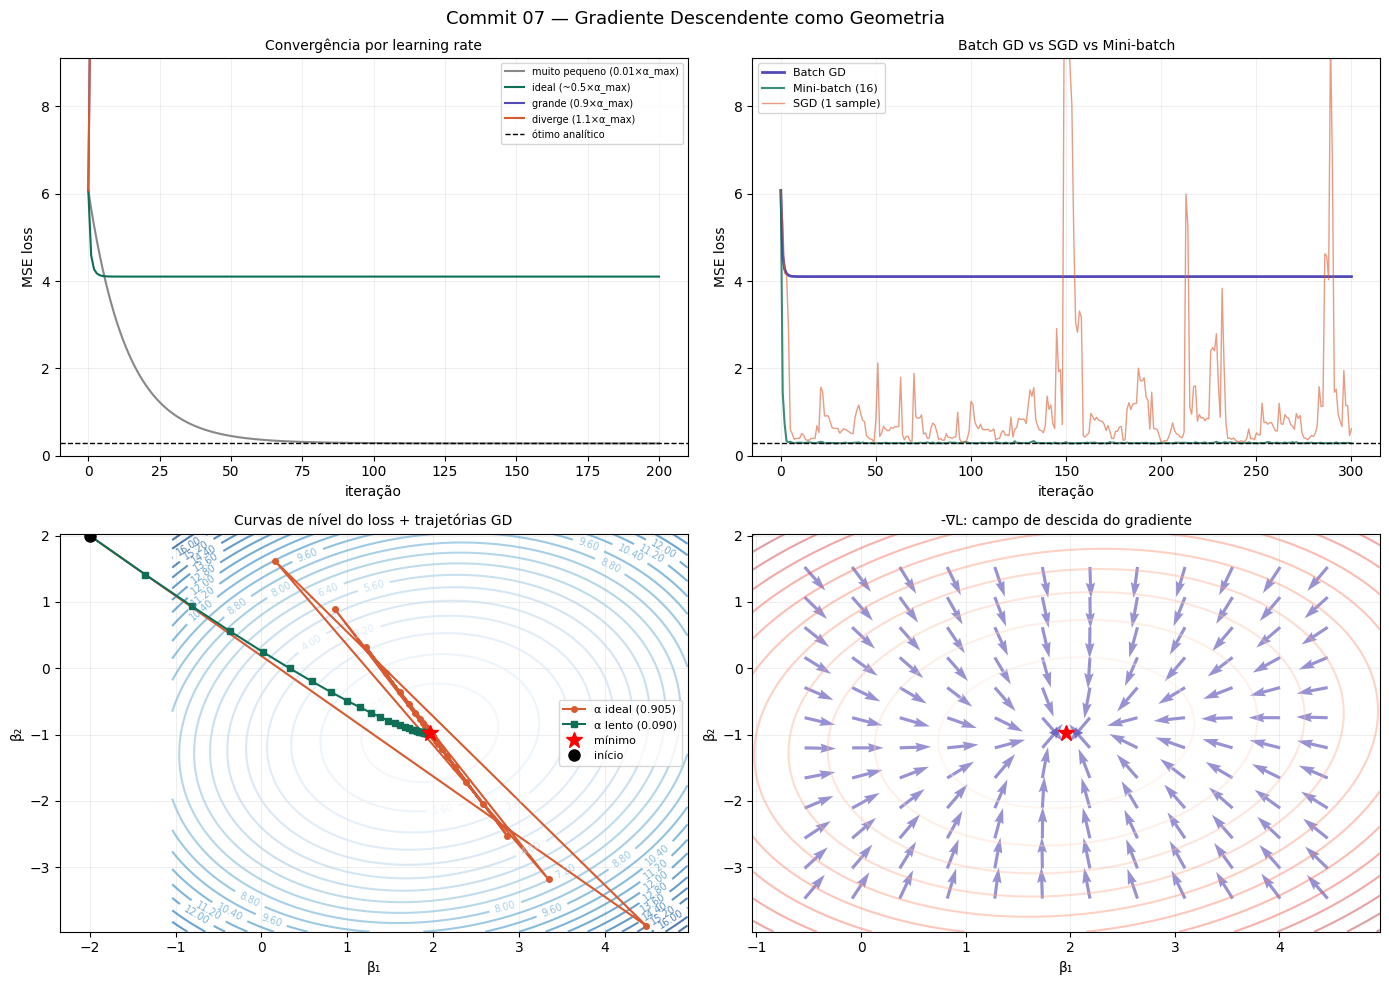

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Commit 07 — Gradiente Descendente como Geometria", fontsize=13)

# Plot 1: loss curves por learning rate
ax = axes[0, 0]
cores_lr = ['#888', '#0F6E56', '#534AB7', '#D85A30']
for (nome, hist), cor in zip(historicos.items(), cores_lr):
    val_clip = np.clip(hist, 0, hist[0]*2)
    ax.plot(val_clip, label=nome, lw=1.5, color=cor)
ax.axhline(loss_otimo, color='black', lw=1, linestyle='--', label='ótimo analítico')
ax.set_xlabel("iteração")
ax.set_ylabel("MSE loss")
ax.set_title("Convergência por learning rate", fontsize=10)
ax.legend(fontsize=7)
ax.set_ylim(0, hist[0]*1.5)
ax.grid(True, alpha=0.2)

# Plot 2: Batch vs SGD
ax2 = axes[0, 1]
ax2.plot(hist_batch, lw=2, color='#534AB7', label='Batch GD')
ax2.plot(hist_sgd16, lw=1.5, color='#0F6E56', alpha=0.8, label='Mini-batch (16)')
ax2.plot(hist_sgd1, lw=1, color='#D85A30', alpha=0.6, label='SGD (1 sample)')
ax2.axhline(loss_otimo, color='black', lw=1, linestyle='--')
ax2.set_xlabel("iteração")
ax2.set_ylabel("MSE loss")
ax2.set_title("Batch GD vs SGD vs Mini-batch", fontsize=10)
ax2.legend(fontsize=8)
ax2.set_ylim(0, hist_batch[0]*1.5)
ax2.grid(True, alpha=0.2)

# Plot 3: curvas de nível + trajetórias
ax3 = axes[1, 0]
cp = ax3.contour(B1, B2, Loss_grid, levels=25, cmap='Blues', alpha=0.7)
ax3.clabel(cp, inline=True, fontsize=7, fmt='%.2f')
ax3.plot(traj_ideal[:, 1], traj_ideal[:, 2], 'o-', color='#D85A30',
         ms=4, lw=1.5, label=f'α ideal ({0.5*alpha_max:.3f})')
ax3.plot(traj_lento[:, 1], traj_lento[:, 2], 's-', color='#0F6E56',
         ms=4, lw=1.5, label=f'α lento ({0.05*alpha_max:.3f})')
ax3.plot(*beta_analitico[1:3], '*', color='red', ms=12, label='mínimo', zorder=5)
ax3.plot(traj_ideal[0, 1], traj_ideal[0, 2], 'ko', ms=8, label='início')
ax3.set_xlabel("β₁")
ax3.set_ylabel("β₂")
ax3.set_title("Curvas de nível do loss + trajetórias GD", fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.2)

# Plot 4: gradiente como campo vetorial
ax4 = axes[1, 1]
b1_coarse = np.linspace(beta_analitico[1]-2.5, beta_analitico[1]+2.5, 12)
b2_coarse = np.linspace(beta_analitico[2]-2.5, beta_analitico[2]+2.5, 12)
G1, G2 = np.meshgrid(b1_coarse, b2_coarse)
U_field = np.zeros_like(G1)
V_field = np.zeros_like(G2)
for i in range(G1.shape[0]):
    for j in range(G1.shape[1]):
        b = np.array([beta0_fixo, G1[i,j], G2[i,j]])
        g = grad_mse(b, X, y)
        U_field[i,j] = -g[1]   # direção negativa = descida
        V_field[i,j] = -g[2]
norms = np.sqrt(U_field**2 + V_field**2) + 1e-8
ax4.quiver(G1, G2, U_field/norms, V_field/norms,
           alpha=0.6, color='#534AB7', scale=20)
ax4.contour(B1, B2, Loss_grid, levels=15, cmap='Reds', alpha=0.4)
ax4.plot(*beta_analitico[1:3], '*', color='red', ms=12, zorder=5)
ax4.set_xlabel("β₁")
ax4.set_ylabel("β₂")
ax4.set_title("-∇L: campo de descida do gradiente", fontsize=10)
ax4.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../assets/07_gradient_descent.png', dpi=150, bbox_inches='tight')
plt.show()
